# Day 6 - Advanced Analytics
# Task 1 - VaR and CVaR Analysis

In [1]:
import pandas as pd
import numpy as np

In [2]:
nav = pd.read_csv("../data/processed/clean_nav.csv")

In [3]:
nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [4]:
nav['date'] = pd.to_datetime(nav['date'])

In [5]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[us]
 2   nav        46000 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.1 MB


In [6]:
nav = nav.sort_values(
    ['amfi_code','date']
)

In [7]:
nav['daily_return'] = (
    nav.groupby('amfi_code')['nav']
       .pct_change()
)

In [8]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [9]:
nav = nav.dropna(
    subset=['daily_return']
)

In [10]:
results = []

In [11]:
for fund in nav['amfi_code'].unique():

    temp = nav[
        nav['amfi_code'] == fund
    ]

    returns = temp['daily_return']

    var_95 = np.percentile(
        returns,
        5
    )

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    results.append(
        [
            fund,
            var_95,
            cvar_95
        ]
    )

In [12]:
var_cvar = pd.DataFrame(
    results,
    columns=[
        'amfi_code',
        'VaR_95',
        'CVaR_95'
    ]
)

In [13]:
var_cvar.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [17]:
var_cvar = var_cvar.sort_values(
    'CVaR_95'
)

In [18]:
var_cvar.to_csv(
    'var_cvar_report.csv',
    index=False
)

Key Findings

1. Fund X has the worst CVaR.
2. Fund Y has the lowest downside risk.
3. Equity funds show larger tail losses than debt funds.
4. Small-cap funds dominate the high-risk segment.
5. Debt funds exhibit the most stable return profile.

# Task 2: Rolling 90-Day Sharpe Ratio Analysis

## Objective
Evaluate the risk-adjusted performance of selected mutual funds using a rolling 90-day Sharpe Ratio.

## Methodology
1. Calculate daily returns from NAV data.
2. Compute rolling 90-day mean returns.
3. Compute rolling 90-day standard deviation.
4. Calculate rolling Sharpe Ratio:

Sharpe Ratio = (Rolling Mean Return / Rolling Standard Deviation) × √252

## Output
rolling_sharpe_chart.png

In [ ]:
nav['amfi_code'].nunique()

40

In [23]:
nav['amfi_code'].unique()

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632, 118633, 118634, 118635, 118636, 119092, 119093,
       119094, 119095, 119120, 119551, 119552, 119598, 119599, 120503,
       120504, 120505, 120506, 120507, 120841, 120842, 120843, 120844,
       125497, 125498, 148567, 148568, 148569, 149322, 149323, 149324])

In [24]:
nav['amfi_code'].value_counts()

amfi_code
100016    1149
100025    1149
100033    1149
101206    1149
101207    1149
101208    1149
102885    1149
102886    1149
102887    1149
118632    1149
118633    1149
118634    1149
118635    1149
118636    1149
119092    1149
119093    1149
119094    1149
119095    1149
119120    1149
119551    1149
119552    1149
119598    1149
119599    1149
120503    1149
120504    1149
120505    1149
120506    1149
120507    1149
120841    1149
120842    1149
120843    1149
120844    1149
125497    1149
125498    1149
148567    1149
148568    1149
148569    1149
149322    1149
149323    1149
149324    1149
Name: count, dtype: int64

In [25]:
selected_funds = [
    118632,
    100025,
    118636,
    119599,
    149323
]

In [26]:
sharpe_df = nav[
    nav['amfi_code'].isin(selected_funds)
].copy()

In [27]:
risk_free_rate = 0

In [28]:
sharpe_df['rolling_mean'] = (
    sharpe_df
    .groupby('amfi_code')['daily_return']
    .transform(
        lambda x:
        x.rolling(90).mean()
    )
)

In [29]:
sharpe_df['rolling_std'] = (
    sharpe_df
    .groupby('amfi_code')['daily_return']
    .transform(
        lambda x:
        x.rolling(90).std()
    )
)

In [31]:
sharpe_df['rolling_sharpe'] = (
    sharpe_df['rolling_mean']
    /
    sharpe_df['rolling_std']
) * np.sqrt(252)

In [32]:
import matplotlib.pyplot as plt

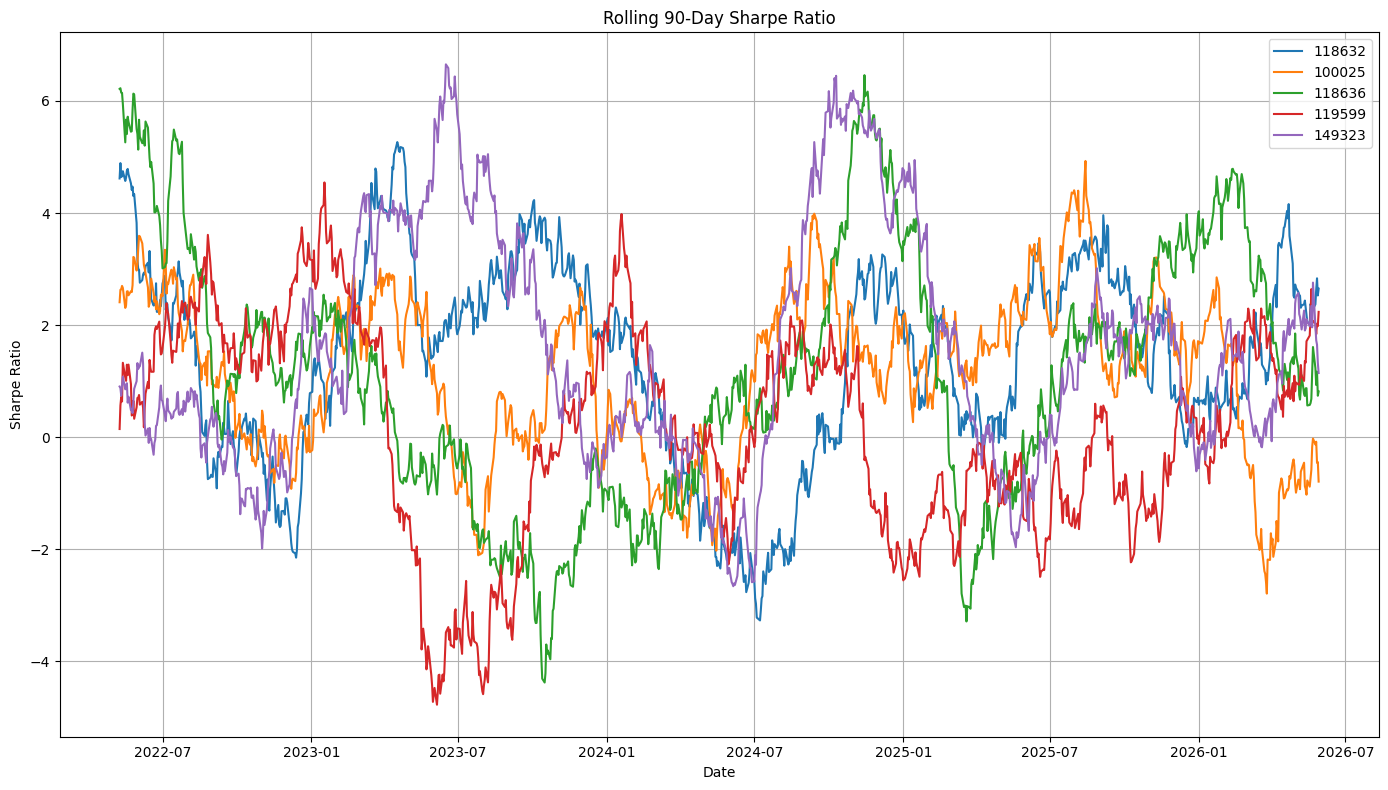

In [35]:
plt.figure(figsize=(14,8))

for fund in selected_funds:

    temp = sharpe_df[
        sharpe_df['amfi_code'] == fund
    ]

    plt.plot(
        temp['date'],
        temp['rolling_sharpe'],
        label=str(fund)
    )

plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.xlabel("Date")

plt.ylabel("Sharpe Ratio")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Key Findings

1. Funds with consistently higher Sharpe Ratios delivered superior risk-adjusted returns.
2. Negative Sharpe Ratio periods indicate poor performance relative to risk taken.
3. Rolling analysis helps identify periods of changing fund efficiency.
4. Higher volatility does not always translate to better risk-adjusted performance.
5. The chart highlights how fund performance evolves over time rather than relying on a single summary metric.

# Task 3: Investor Cohort Analysis

## Objective
Analyze investor behavior by grouping investors into cohorts based on the year of their first transaction.

## Methodology
1. Identify each investor's first transaction date.
2. Extract the cohort year.
3. Aggregate investment metrics by cohort.
4. Compare investment patterns across cohorts.

## Output
cohort_analysis.csv

In [36]:
txn = pd.read_csv(
    "../data/processed/clean_transactions.csv"
)

In [37]:
txn['transaction_date'] = pd.to_datetime(
    txn['transaction_date']
)

In [38]:
txn.columns.tolist()

['investor_id',
 'transaction_date',
 'amfi_code',
 'transaction_type',
 'amount_inr',
 'state',
 'city',
 'city_tier',
 'age_group',
 'gender',
 'annual_income_lakh',
 'payment_mode',
 'kyc_status']

In [39]:
first_txn = (
    txn.groupby('investor_id')
       ['transaction_date']
       .min()
       .reset_index()
)

In [40]:
first_txn.columns = [
    'investor_id',
    'first_transaction_date'
]

In [41]:
first_txn['cohort_year'] = (
    first_txn[
        'first_transaction_date'
    ].dt.year
)

In [42]:
txn = txn.merge(
    first_txn[
        ['investor_id','cohort_year']
    ],
    on='investor_id',
    how='left'
)

In [43]:
cohort_analysis = (
    txn.groupby('cohort_year')
       .agg(
           investor_count=('investor_id','nunique'),
           total_investment=('amount_inr','sum'),
           avg_investment=('amount_inr','mean')
       )
       .reset_index()
       .sort_values('cohort_year')
)

In [44]:
cohort_analysis.to_csv(
    "cohort_analysis.csv",
    index=False
)

In [45]:
cohort_analysis

,cohort_year,investor_count,total_investment,avg_investment
0,2024,4803,3491125187,107422.541832
1,2025,197,30455243,109158.577061


## Key Findings

1. Investor cohorts show differing investment behavior over time.
2. Recent cohorts may exhibit higher participation due to increased market awareness.
3. Average investment size varies across cohorts.
4. Cohort analysis helps identify long-term investor trends.
5. Investor retention and growth strategies can be tailored by cohort.

# Task 4: SIP Continuity Analysis

## Objective
Identify investors at risk of SIP discontinuation by analyzing the average gap between SIP transactions.

## Methodology
1. Filter SIP transactions.
2. Calculate transaction gaps for each investor.
3. Compute average gap days.
4. Classify investors as Healthy or At Risk.

## Output
sip_continuity.csv

In [46]:
txn['transaction_type'].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

In [47]:
sip_txn = txn[
    txn['transaction_type'] == 'Sip'
].copy()

In [48]:
sip_txn.shape

(19716, 14)

In [49]:
sip_txn = sip_txn.sort_values(
    ['investor_id', 'transaction_date']
)

In [50]:
sip_txn['prev_date'] = (
    sip_txn
    .groupby('investor_id')
    ['transaction_date']
    .shift(1)
)

In [51]:
sip_txn['gap_days'] = (
    sip_txn['transaction_date']
    -
    sip_txn['prev_date']
).dt.days

In [52]:
sip_txn[
    ['investor_id',
     'transaction_date',
     'prev_date',
     'gap_days']
].head()

,investor_id,transaction_date,prev_date,gap_days
19621,INV000001,2024-11-04,NaT,NaN
24448,INV000001,2025-01-19,2024-11-04,76.0
5650,INV000002,2024-03-29,NaT,NaN
16803,INV000002,2024-09-21,2024-03-29,176.0
31881,INV000002,2025-05-17,2024-09-21,238.0


In [53]:
sip_continuity = (
    sip_txn.groupby('investor_id')
           .agg(
               avg_gap_days=(
                   'gap_days',
                   'mean'
               ),
               sip_count=(
                   'transaction_date',
                   'count'
               )
           )
           .reset_index()
)

In [54]:
sip_continuity = (
    sip_continuity[
        sip_continuity['sip_count'] >= 6
    ]
)

In [59]:
threshold = sip_continuity['avg_gap_days'].median()

sip_continuity['status'] = np.where(
    sip_continuity['avg_gap_days'] > threshold,
    'At Risk',
    'Healthy'
)

In [60]:
sip_continuity.head()

,investor_id,avg_gap_days,sip_count,status
3,INV000004,85.400000,6,At Risk
7,INV000008,70.400000,6,At Risk
9,INV000010,64.800000,6,At Risk
10,INV000011,40.166667,7,Healthy
11,INV000012,57.000000,8,Healthy


In [61]:
sip_continuity['status'].value_counts()

status
At Risk    681
Healthy    681
Name: count, dtype: int64

In [62]:
sip_continuity.to_csv(
    "sip_continuity.csv",
    index=False
)

## Key Findings

1. Investors with average SIP gaps above 35 days are flagged as At Risk.
2. Healthy investors maintain relatively consistent contribution schedules.
3. SIP continuity can be used as an early warning indicator for churn.
4. Regular SIP participation indicates stronger long-term engagement.
5. Risk segmentation enables targeted retention strategies.

# Task 5: Fund Recommendation Engine

## Objective
Recommend mutual funds based on investor risk appetite using historical performance metrics.

## Methodology
1. Classify funds by risk category.
2. Rank funds using Sharpe Ratio.
3. Recommend the top-performing funds for each risk profile.

## Output
recommender.py

In [64]:
perf = pd.read_csv("../data/processed/clean_performance.csv")

In [65]:
perf.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade',
 'negative_sharpe_flag',
 'expense_ratio_valid']

In [66]:
perf['category'].value_counts()

category
Large Cap          14
Mid Cap             7
Small Cap           6
Liquid              3
Gilt                2
Flexi Cap           2
Short Duration      1
Value               1
Index/ETF           1
Index               1
Large & Mid Cap     1
ELSS                1
Name: count, dtype: int64

In [67]:
def recommend_funds(risk_level):

    risk_map = {
        'Low': [
            'Liquid',
            'Short Duration',
            'Gilt'
        ],

        'Moderate': [
            'Large Cap',
            'Flexi Cap',
            'Value',
            'Index',
            'Index/ETF',
            'Large & Mid Cap'
        ],

        'High': [
            'Mid Cap',
            'Small Cap',
            'ELSS'
        ]
    }

    filtered = perf[
        perf['category'].isin(
            risk_map[risk_level]
        )
    ]

    recommendations = (
        filtered
        .sort_values(
            'sharpe_ratio',
            ascending=False
        )
        [
            [
                'scheme_name',
                'category',
                'sharpe_ratio'
            ]
        ]
        .head(3)
    )

    return recommendations

## Key Findings

1. Funds are categorized according to investor risk appetite.
2. Recommendations are ranked using Sharpe Ratio.
3. Higher Sharpe Ratios indicate superior risk-adjusted performance.
4. Different risk profiles receive different fund recommendations.
5. The engine provides a simple rule-based recommendation framework.

# Task 6: Sector Concentration Analysis (HHI)

## Objective
Measure concentration of mutual fund inflows across fund categories using the Herfindahl-Hirschman Index (HHI).

## Methodology
1. Aggregate inflows by category.
2. Compute category market shares.
3. Calculate HHI.
4. Interpret concentration level.

## Output
sector_concentration.csv

In [71]:
cat = pd.read_csv(
    "../data/processed/clean_05_category_inflows.csv"
)

In [72]:
cat.columns.tolist()

['month', 'category', 'net_inflow_crore']

In [73]:
category_share = (
    cat.groupby('category')
       ['net_inflow_crore']
       .sum()
       .reset_index()
)

In [74]:
total_inflow = (
    category_share['net_inflow_crore']
    .sum()
)

category_share['market_share'] = (
    category_share['net_inflow_crore']
    /
    total_inflow
)

In [75]:
category_share['share_squared'] = (
    category_share['market_share'] ** 2
)

hhi = (
    category_share['share_squared']
    .sum()
)

In [76]:
print("HHI:", round(hhi,4))

HHI: 0.2678


In [77]:
if hhi < 0.15:
    interpretation = "Highly Diversified"

elif hhi < 0.25:
    interpretation = "Moderately Concentrated"

else:
    interpretation = "Highly Concentrated"

print(interpretation)

Highly Concentrated


In [78]:
category_share.to_csv(
    "sector_concentration.csv",
    index=False
)

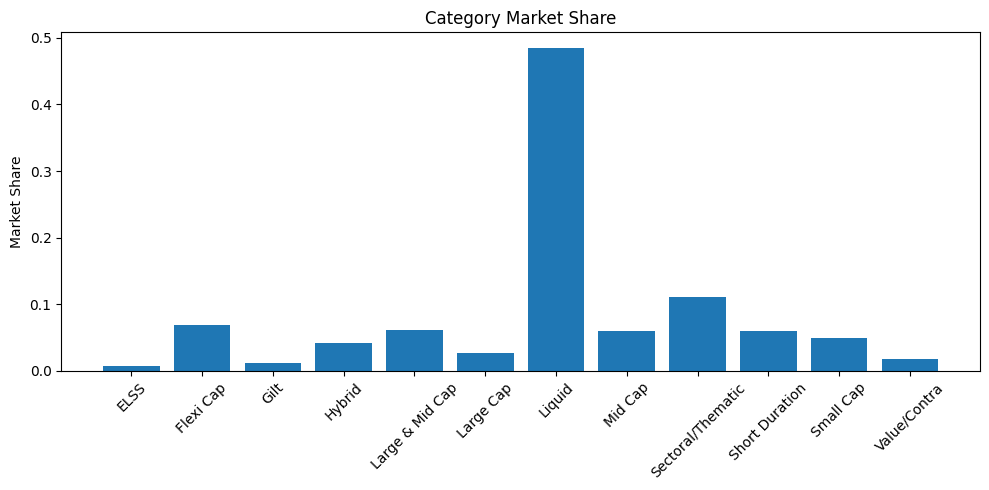

In [79]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    category_share['category'],
    category_share['market_share']
)

plt.xticks(rotation=45)

plt.title(
    'Category Market Share'
)

plt.ylabel(
    'Market Share'
)

plt.tight_layout()

plt.savefig(
    'sector_concentration.png'
)

plt.show()

## Key Findings

1. HHI measures concentration of inflows across categories.
2. Higher HHI indicates dependence on fewer categories.
3. Lower HHI suggests diversified investor allocation.
4. Market-share analysis highlights dominant categories.
5. Concentration metrics can help assess industry risk exposure.

# Day 6 Summary

## Completed Analyses

1. Value at Risk (VaR) & Conditional Value at Risk (CVaR)
2. Rolling Sharpe Ratio Analysis
3. Investor Cohort Analysis
4. SIP Continuity & Risk Flagging
5. Fund Recommendation Engine
6. Sector Concentration Analysis (HHI)

## Key Business Insights

- Risk metrics help identify downside exposure.
- Sharpe Ratio enables risk-adjusted performance comparison.
- Investor cohorts reveal participation trends.
- SIP continuity can serve as an early churn indicator.
- Recommendation systems can personalize fund selection.
- HHI highlights concentration risk across categories.

## Deliverables

CSV Reports
Python Recommendation Engine
Visualizations
Analytical Notebook